# ЛР2 «Виртуальный датчик для контроля процесса обжига в печи»

## Цель
Построить пайплайн прогнозирования целевого показателя (лабораторные замеры) в текущий момент времени на основе минутной телеметрии печи с учётом временной задержки (10–15 минут).

## Входные данные
- `data_train.csv`: минутные измерения 16 телеметрических сигналов `telemetry_0..telemetry_15`
- `target_train.csv`: нерегулярные лабораторные замеры `Дата` (время **получения результата лабораторией**) и `target`

## Что реализовано в ноутбуке
1) EDA (пропуски/выбросы/тренды/распределение целевой)
2) Синхронизация источников с задержкой (поиск оптимального сдвига в окне 10–15 минут)
3) Инжиниринг признаков временных рядов (lags, rolling stats, производные)
4) Минимум 3 модели + метрики качества + остатки + важность признаков и интерпретация


In [17]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_TRAIN_PATH = 'data_train.csv'
TARGET_TRAIN_PATH = 'target_train.csv'

CONFIG = {
                                                                                      
    'delay_candidates_min': [10, 11, 12, 13, 14, 15],

    'max_lag_min': 60,
    'lag_list_min': [1, 5, 10, 15, 30, 60],

    'rolling_windows_min': [10, 20, 60],

    'drop_col_missing_ratio_threshold': 0.95,

    'train_fraction': 0.80,

    'random_seed': 42,

    'delay_tune_n_estimators': 200,

    'extra_trees_n_estimators': 800,
    'extra_trees_max_depth': None,
    'rf_n_estimators': 800,
}

np.random.seed(CONFIG['random_seed'])


## 2.1. Разведочный анализ данных (EDA)

Ниже:
- загрузка `data_train.csv` (минутная телеметрия) и `target_train.csv` (лабораторные замеры)
- анализ пропусков/дубликатов/выбросов
- базовый анализ целевой переменной и временной структуры

Telemetry rows: 319546
Telemetry unique minutes: 317998
Telemetry duplicate rows: 1548
Target rows: 1773
Target unique timestamps: 1773

Top missing telemetry columns (fraction NaN):
telemetry_12    0.993406
telemetry_13    0.993406
telemetry_14    0.993406
telemetry_15    0.993406
telemetry_4     0.000418
telemetry_0     0.000053
telemetry_5     0.000053
telemetry_1     0.000050
telemetry_2     0.000050
telemetry_3     0.000050
dtype: float64

Keep telemetry columns: 12
Drop telemetry columns: 4 -> ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']

Processed telemetry shape: (317998, 12)
Processed target shape: (1773, 1)


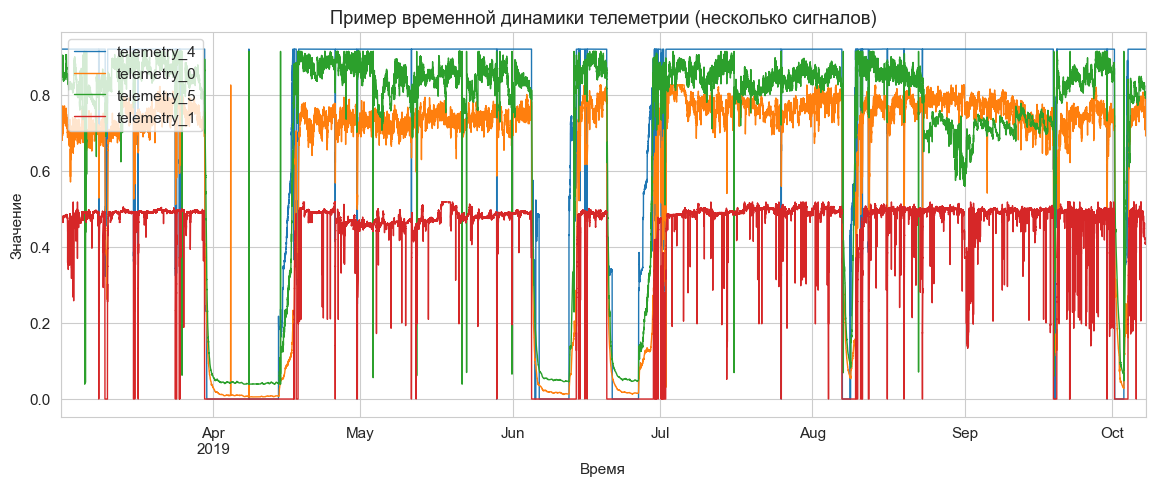

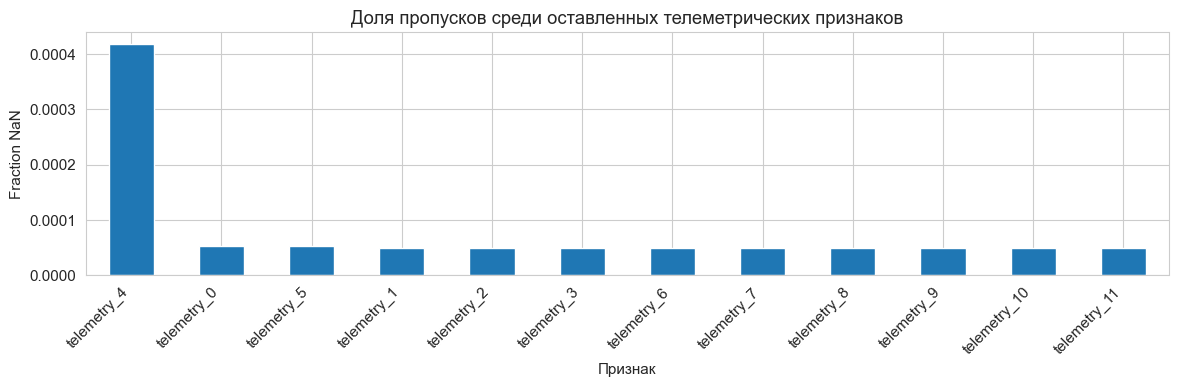

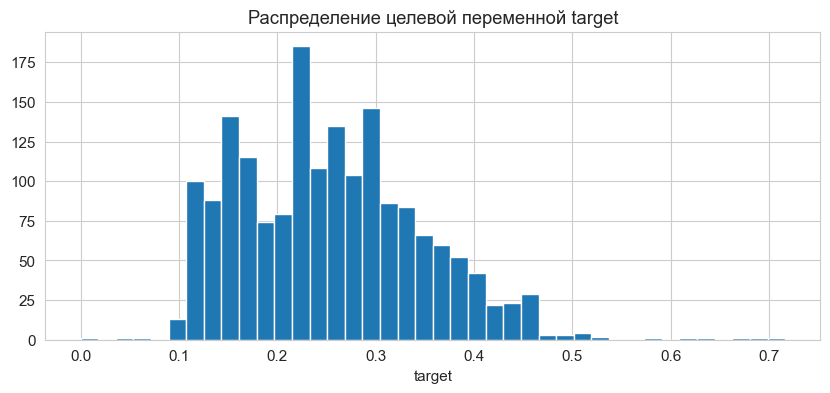

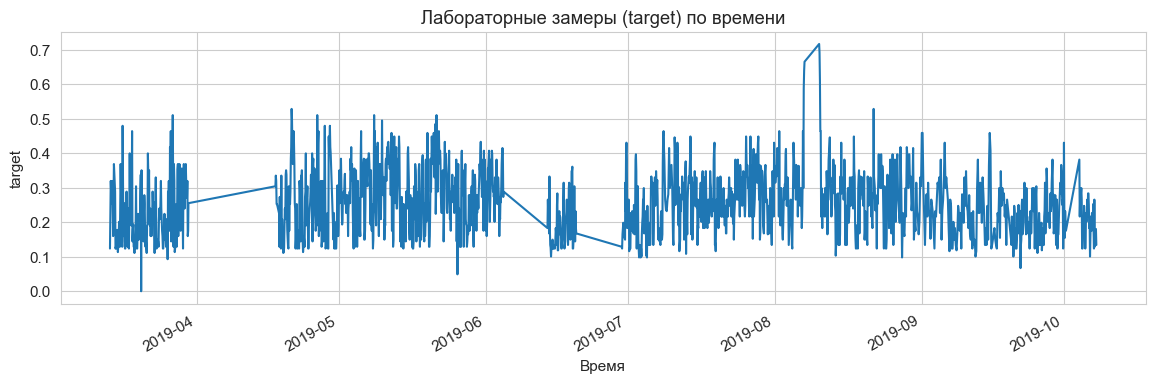


Unique minutes in target (minute component): [0, 30]
Target time span: 2019-03-13 17:00:00 -> 2019-10-07 21:00:00
Telemetry time span: 2019-03-01 00:01:00 -> 2019-10-07 19:58:00


In [18]:
                    
# Загрузка минутной телеметрии и лабораторных точек
telemetry_raw = pd.read_csv(DATA_TRAIN_PATH)
target_raw = pd.read_csv(TARGET_TRAIN_PATH)

telemetry_raw['datetime'] = pd.to_datetime(telemetry_raw['datetime'])
target_raw['Дата'] = pd.to_datetime(target_raw['Дата'])

print('Telemetry rows:', len(telemetry_raw))
print('Telemetry unique minutes:', telemetry_raw['datetime'].nunique())
print('Telemetry duplicate rows:', telemetry_raw.duplicated('datetime').sum())

print('Target rows:', len(target_raw))
print('Target unique timestamps:', target_raw['Дата'].nunique())

# Дубликаты по времени усредняем
telemetry = (
    telemetry_raw
    .groupby('datetime', as_index=False)
    .mean(numeric_only=True)
    .sort_values('datetime')
)

telemetry = telemetry.set_index('datetime').sort_index()

telemetry_cols = [c for c in telemetry.columns if c.startswith('telemetry_')]

missing_ratio = telemetry[telemetry_cols].isna().mean().sort_values(ascending=False)
print('\nTop missing telemetry columns (fraction NaN):')
print(missing_ratio.head(10))

# Отбрасываем почти пустые каналы
keep_cols = missing_ratio[missing_ratio <= CONFIG['drop_col_missing_ratio_threshold']].index.tolist()
dropped_cols = [c for c in telemetry_cols if c not in keep_cols]

print(f"\nKeep telemetry columns: {len(keep_cols)}")
print(f"Drop telemetry columns: {len(dropped_cols)} -> {dropped_cols}")

telemetry = telemetry[keep_cols].copy()

# Заполняем пропуски в рабочей телеметрии
telemetry = telemetry.interpolate(method='time', limit_direction='both')
telemetry = telemetry.ffill().bfill()

q_low, q_high = 0.01, 0.99
for c in keep_cols:
    lo = telemetry[c].quantile(q_low)
    hi = telemetry[c].quantile(q_high)
    telemetry[c] = telemetry[c].clip(lo, hi)

target = target_raw.sort_values('Дата').set_index('Дата')
target.rename(columns={'target': 'target'}, inplace=True)

print('\nProcessed telemetry shape:', telemetry.shape)
print('Processed target shape:', target.shape)

fig, ax = plt.subplots(figsize=(14, 5))
                                                                
show_cols = keep_cols[:4] if len(keep_cols) >= 4 else keep_cols
telemetry[show_cols].plot(ax=ax, linewidth=1)
ax.set_title('Пример временной динамики телеметрии (несколько сигналов)')
ax.set_xlabel('Время')
ax.set_ylabel('Значение')
plt.legend(loc='upper left')
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
missing_ratio.loc[keep_cols].plot(kind='bar', ax=ax)
ax.set_title('Доля пропусков среди оставленных телеметрических признаков')
ax.set_xlabel('Признак')
ax.set_ylabel('Fraction NaN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
target['target'].hist(bins=40, ax=ax)
ax.set_title('Распределение целевой переменной target')
ax.set_xlabel('target')
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
target['target'].plot(ax=ax)
ax.set_title('Лабораторные замеры (target) по времени')
ax.set_xlabel('Время')
ax.set_ylabel('target')
plt.show()

minute_set = sorted(target.index.minute.unique().tolist())
print('\nUnique minutes in target (minute component):', minute_set)
print('Target time span:', str(target.index.min()), '->', str(target.index.max()))

print('Telemetry time span:', str(telemetry.index.min()), '->', str(telemetry.index.max()))


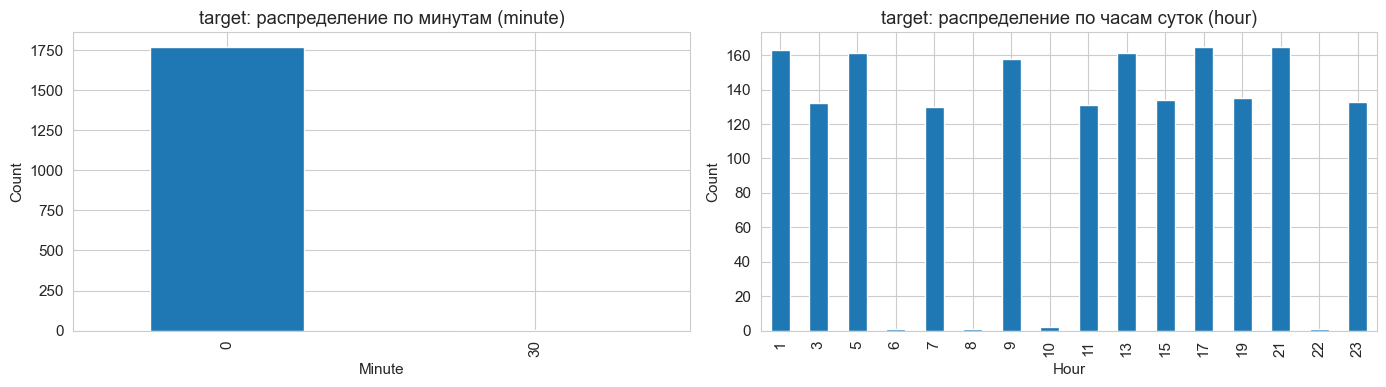

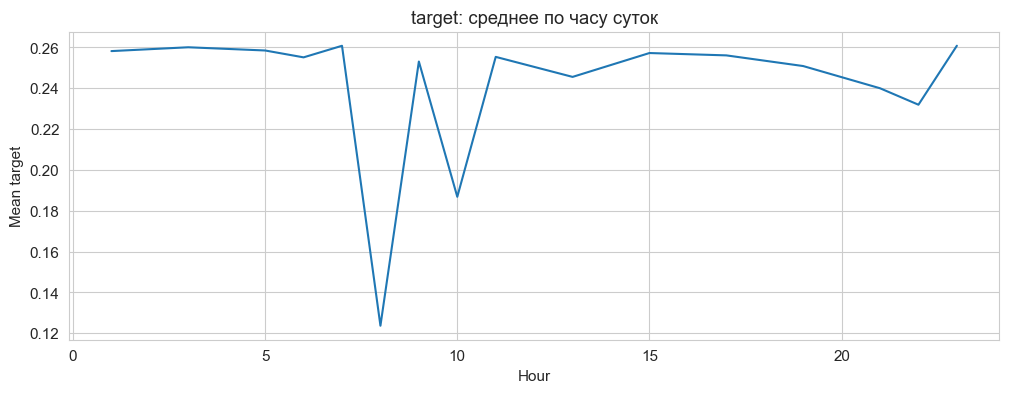

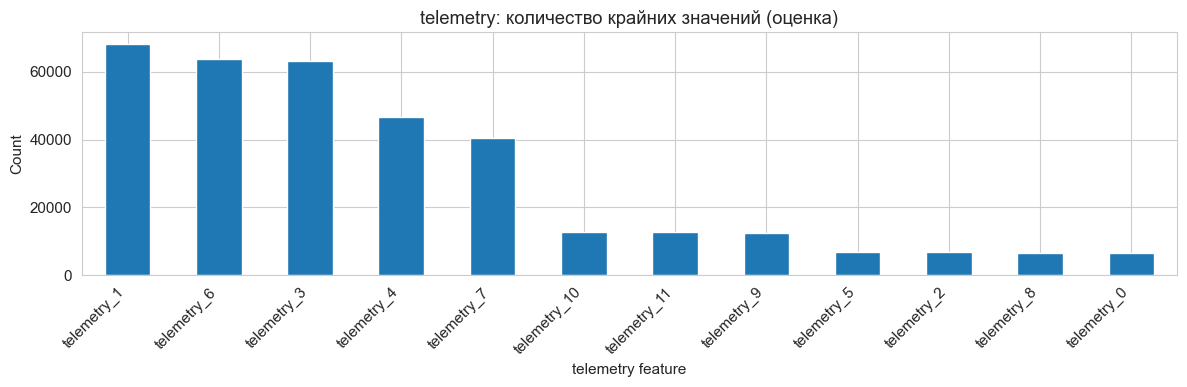


Доля оставшихся телеметрических признаков: 12


In [19]:
                                
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
target.index.minute.value_counts().sort_index().plot(kind='bar', ax=ax[0])
ax[0].set_title('target: распределение по минутам (minute)')
ax[0].set_xlabel('Minute')
ax[0].set_ylabel('Count')

target.index.hour.value_counts().sort_index().plot(kind='bar', ax=ax[1])
ax[1].set_title('target: распределение по часам суток (hour)')
ax[1].set_xlabel('Hour')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

hour_means = target['target'].groupby(target.index.hour).mean()
fig, ax = plt.subplots(figsize=(12, 4))
hour_means.plot(ax=ax)
ax.set_title('target: среднее по часу суток')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean target')
plt.show()

outlier_counts = {}
for c in keep_cols:
    lo = telemetry[c].quantile(0.01)
    hi = telemetry[c].quantile(0.99)
                                                           
    outlier_counts[c] = ((telemetry[c] <= lo) | (telemetry[c] >= hi)).sum()

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 4))
outlier_series.head(12).plot(kind='bar', ax=ax)
ax.set_title('telemetry: количество крайних значений (оценка)')
ax.set_xlabel('telemetry feature')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nДоля оставшихся телеметрических признаков:', len(keep_cols))


### Выводы по 2.1 (EDA)

- Дубликаты по `datetime` убраны через агрегацию по времени.
- Каналы `telemetry_12..telemetry_15` исключены: почти полностью состоят из пропусков.
- Пропуски в рабочих признаках заполнены интерполяцией по времени + `ffill/bfill`.
- Лабораторные точки нерегулярны, но по минутам в основном `:00` и `:30`, поэтому лаговая синхронизация работает стабильно.

   delay_min  n_samples       mae
4         14       1772  0.080954
1         11       1772  0.081096
5         15       1772  0.081494
2         12       1772  0.081531
3         13       1772  0.081690
0         10       1772  0.082013

Best delay (min) by MAE: 14


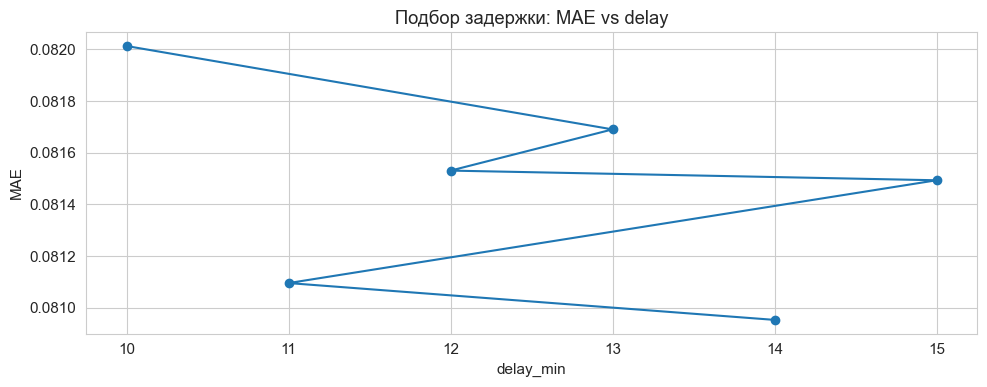

In [20]:
                                                             
from typing import Iterable, Tuple

feature_cols_cache = {}

def build_supervised_dataset(
    telemetry_df: pd.DataFrame,
    target_df: pd.DataFrame,
    delay_min: int,
    lag_list_min: list,
    rolling_windows_min: list,
    telemetry_cols: list,
    rolling_stats: Tuple[str, ...] = ('mean', 'std'),
    include_derivatives: bool = False,
):
    """Строит матрицу признаков X для предсказания y(t_lab) из телеметрии
    в момент отбора пробы anchor = t_lab - delay_min.

    Важно: rolling-статистики считаются по телеметрии в минутной сетке
    и берутся в точке `anchor_time`.
    """

    assert set(rolling_stats).issubset({'mean', 'std', 'min', 'max'})

    anchor_times = target_df.index - pd.Timedelta(minutes=delay_min)

    X = {
        'hour_of_day': anchor_times.hour,
        'day_of_week': anchor_times.dayofweek,
        'month': anchor_times.month,
        'minute_of_hour': anchor_times.minute,
    }

    for col in telemetry_cols:
        s = telemetry_df[col]

        for lag in lag_list_min:
            t = anchor_times - pd.Timedelta(minutes=lag)
            X[f'{col}_lag_{lag}'] = s.reindex(t).to_numpy()

        if include_derivatives:
            diff1 = s.diff(1)
            X[f'{col}_diff_1'] = diff1.reindex(anchor_times).to_numpy()

            pct1 = s.pct_change(1)
            X[f'{col}_pct_change_1'] = pct1.reindex(anchor_times).to_numpy()

        for w in rolling_windows_min:
            if 'mean' in rolling_stats:
                X[f'{col}_roll_mean_{w}'] = s.rolling(window=w, min_periods=max(2, w // 2)).mean().reindex(anchor_times).to_numpy()
            if 'std' in rolling_stats:
                X[f'{col}_roll_std_{w}'] = s.rolling(window=w, min_periods=max(2, w // 2)).std().reindex(anchor_times).to_numpy()
            if 'min' in rolling_stats:
                X[f'{col}_roll_min_{w}'] = s.rolling(window=w, min_periods=max(2, w // 2)).min().reindex(anchor_times).to_numpy()
            if 'max' in rolling_stats:
                X[f'{col}_roll_max_{w}'] = s.rolling(window=w, min_periods=max(2, w // 2)).max().reindex(anchor_times).to_numpy()

    X_df = pd.DataFrame(X, index=target_df.index)
    y = target_df['target'].copy()

    valid_mask = X_df.notna().all(axis=1)
    X_df = X_df.loc[valid_mask]
    y = y.loc[valid_mask]

    return X_df, y

telemetry_cols_used = [c for c in telemetry.columns]

def time_split_by_fraction(X: pd.DataFrame, y: pd.Series, train_fraction: float):
    n = len(y)
    split = int(n * train_fraction)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    return X_train, X_test, y_train, y_test

delay_results = []
for delay_min in CONFIG['delay_candidates_min']:
    X, y = build_supervised_dataset(
        telemetry_df=telemetry,
        target_df=target,
        delay_min=delay_min,
        lag_list_min=CONFIG['lag_list_min'],
        rolling_windows_min=CONFIG['rolling_windows_min'],
        telemetry_cols=telemetry_cols_used,
        rolling_stats=(),
        include_derivatives=False,
    )

    X_train, X_test, y_train, y_test = time_split_by_fraction(X, y, CONFIG['train_fraction'])

    model = ExtraTreesRegressor(
        n_estimators=CONFIG['delay_tune_n_estimators'],
        random_state=CONFIG['random_seed'],
        n_jobs=-1,
        max_depth=None,
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    delay_results.append({'delay_min': delay_min, 'n_samples': len(y), 'mae': mae})

res_delay = pd.DataFrame(delay_results).sort_values('mae')
print(res_delay)

best_delay = int(res_delay.iloc[0]['delay_min'])
print(f"\nBest delay (min) by MAE: {best_delay}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(res_delay['delay_min'], res_delay['mae'], marker='o')
ax.set_title('Подбор задержки: MAE vs delay')
ax.set_xlabel('delay_min')
ax.set_ylabel('MAE')
plt.tight_layout()
plt.show()


### Вывод по 2.1 (синхронизация)

Ниже будет:
- подобрана лучшая задержка `best_delay` (в пределах 10–15 минут) по time-based split;
- показана корреляционная структура между `target` и телеметрией на разных лаговых смещениях (обоснование лаговых признаков для 2.2).

best_delay = 14 minutes

Top telemetry columns by |corr| across lags:
telemetry
telemetry_0    0.174296
telemetry_3    0.167077
telemetry_9    0.121460
telemetry_6    0.106759
telemetry_8    0.103496
telemetry_4    0.100468
dtype: float64


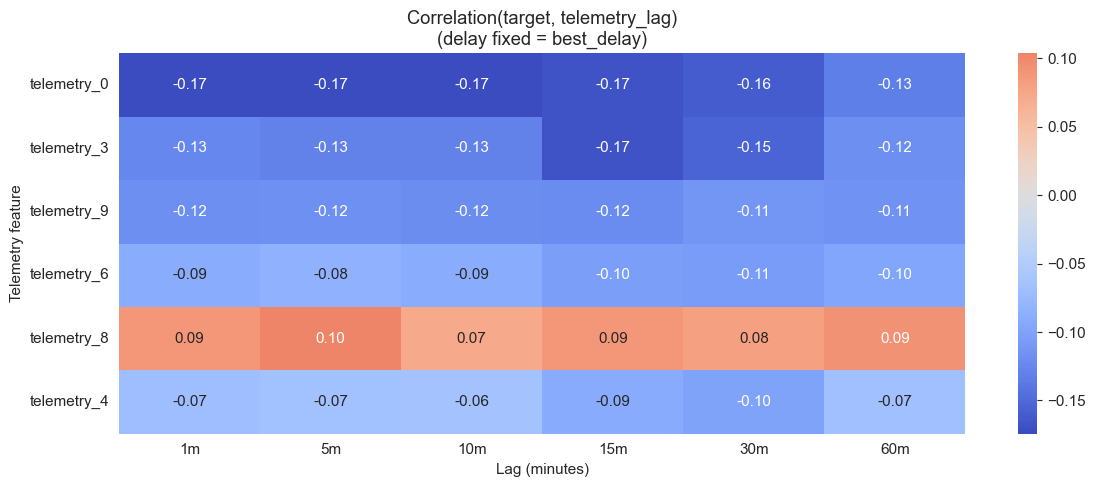

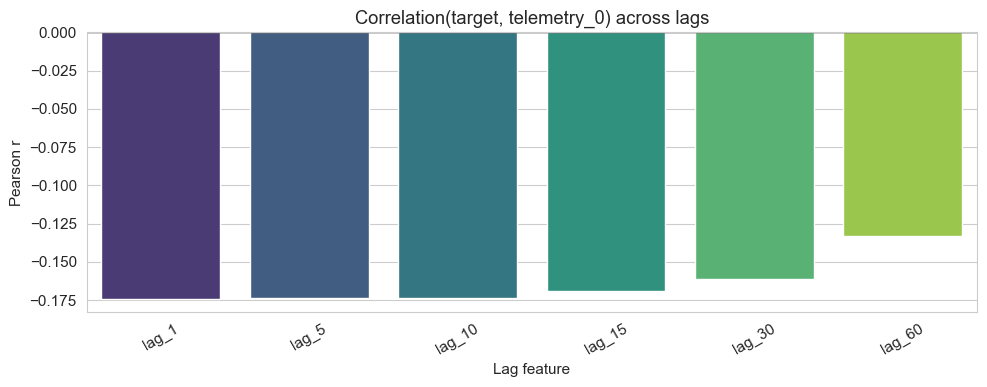

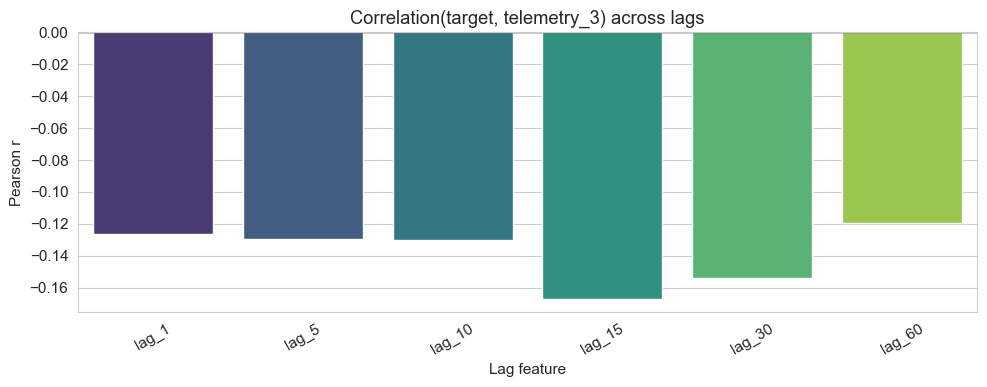

In [21]:
                                                                         
print('best_delay =', best_delay, 'minutes')

anchor_times = target.index - pd.Timedelta(minutes=best_delay)
lag_list = CONFIG['lag_list_min']

cols_for_corr = telemetry.columns.tolist()

corr_rows = []
for col in cols_for_corr:
    row = {'telemetry': col}
    for lag in lag_list:
        t = anchor_times - pd.Timedelta(minutes=lag)
        vals = telemetry[col].reindex(t).to_numpy()
        y_vals = target['target'].to_numpy()
        mask = np.isfinite(vals) & np.isfinite(y_vals)
        if mask.sum() < 30:
            row[f'lag_{lag}'] = np.nan
            continue
        row[f'lag_{lag}'] = np.corrcoef(vals[mask], y_vals[mask])[0, 1]
    corr_rows.append(row)

corr_df = pd.DataFrame(corr_rows).set_index('telemetry')

absmax = corr_df.abs().max(axis=1).sort_values(ascending=False)
top_cols = absmax.head(6).index.tolist()
print('\nTop telemetry columns by |corr| across lags:')
print(absmax.head(6))

heat_df = corr_df.loc[top_cols, :].copy()
heat_df = heat_df.rename(columns={f'lag_{l}': f'{l}m' for l in lag_list})

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation(target, telemetry_lag)\n(delay fixed = best_delay)')
ax.set_xlabel('Lag (minutes)')
ax.set_ylabel('Telemetry feature')
plt.tight_layout()
plt.show()

for col in top_cols[:2]:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = [f'lag_{l}' for l in lag_list]
    sns.barplot(x=x, y=corr_df.loc[col, x].values, ax=ax, palette='viridis')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Correlation(target, {col}) across lags')
    ax.set_xlabel('Lag feature')
    ax.set_ylabel('Pearson r')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 2.2. Инжиниринг признаков для временных рядов

Идея: под цель `target(t_lab)` берём телеметрию на момент `anchor = t_lab - delay`, а затем добавляем признаки:
- лаги телеметрии `telemetry_*_lag_k`
- скользящие статистики `rolling mean/std/min/max` на разных окнах
- динамику изменений: производные (`diff`, `pct_change`)
- календарные признаки (час/день недели/месяц)

Далее эти признаки будут использованы для обучения 3 моделей (2.3).

In [22]:
                                      
# Финальный датасет признаков для найденной задержки
X_all, y_all = build_supervised_dataset(
    telemetry_df=telemetry,
    target_df=target,
    delay_min=best_delay,
    lag_list_min=CONFIG['lag_list_min'],
    rolling_windows_min=CONFIG['rolling_windows_min'],
    telemetry_cols=list(telemetry.columns),
    rolling_stats=('mean', 'std', 'min', 'max'),
    include_derivatives=True,
)

print('X_all shape:', X_all.shape)
print('y_all shape:', y_all.shape)
print('X columns example:', list(X_all.columns[:10]))

# Time-based holdout: первые 80% train, последние 20% test
split = int(len(y_all) * CONFIG['train_fraction'])
X_train, X_test = X_all.iloc[:split], X_all.iloc[split:]
y_train, y_test = y_all.iloc[:split], y_all.iloc[split:]

print('\nTrain samples:', len(y_train), 'Test samples:', len(y_test))
print('Train time span:', str(y_train.index.min()), '->', str(y_train.index.max()))
print('Test  time span:', str(y_test.index.min()), '->', str(y_test.index.max()))

from sklearn.feature_selection import mutual_info_regression

# Для OLS оставляем ограниченное число информативных признаков
mi = mutual_info_regression(X_train.values, y_train.values, random_state=CONFIG['random_seed'])

k_ols = min(120, X_train.shape[1])
idx_top = np.argsort(mi)[-k_ols:]
selected_features_for_ols = X_train.columns[idx_top].tolist()

print(f"\nSelected features for OLS: k={k_ols}")
print('First 15 selected features:', selected_features_for_ols[:15])


X_all shape: (1762, 244)
y_all shape: (1762,)
X columns example: ['hour_of_day', 'day_of_week', 'month', 'minute_of_hour', 'telemetry_4_lag_1', 'telemetry_4_lag_5', 'telemetry_4_lag_10', 'telemetry_4_lag_15', 'telemetry_4_lag_30', 'telemetry_4_lag_60']

Train samples: 1409 Test samples: 353
Train time span: 2019-03-13 17:00:00 -> 2019-08-24 03:00:00
Test  time span: 2019-08-24 05:00:00 -> 2019-10-07 19:00:00

Selected features for OLS: k=120
First 15 selected features: ['telemetry_10_lag_10', 'telemetry_10_lag_15', 'telemetry_3_lag_1', 'telemetry_5_lag_30', 'telemetry_8_roll_max_10', 'telemetry_10_lag_30', 'telemetry_8_lag_5', 'telemetry_0_roll_std_10', 'telemetry_10_roll_std_60', 'telemetry_10_roll_min_60', 'telemetry_10_roll_max_60', 'telemetry_6_pct_change_1', 'telemetry_4_lag_15', 'telemetry_4_roll_mean_10', 'telemetry_10_lag_60']


## 2.3. Построение прогнозных моделей

Так как целевая переменная `target` приходит нерегулярно и с временной задержкой, а в качестве объясняющих сигналов выступает **многомерная** телеметрия, удобно перейти к задаче **регрессии по лаговым/rolling-признакам**.

Ниже обучаем 3 модели:
- `OLS (statsmodels)`: статистическая линейная модель по отобранным признакам. Позволяет интерпретировать коэффициенты и даёт AIC/BIC.
- `ExtraTreesRegressor`: ансамбль деревьев, хорошо работает на нелинейностях и взаимодействиях, устойчив к нелинейным зависимостям.
- `RandomForestRegressor`: вторая ансамблевая модель для сравнения и проверки качества/стабильности.

Какие модели **точно хуже подойдут** и почему:
- `ARIMA/SARIMA` напрямую на `target`: серия нерегулярная (лабораторные точки не в минутной сетке), а также фактически связь с телеметрией задана через задержку и лаги. Без грамотной ресэмплинг-стратегии высок риск искажения структуры.
- `VAR/VECM`: требуют стационарности и корректной структуры долгосрочных связей (коинтеграции). Здесь мы фактически используем очень много телеметрических признаков (высокая размерность при ограниченном числе лабораторных наблюдений), что делает параметризацию и проверку предпосылок проблемными.
- `TCN/LSTM`: нейросети для последовательностей могут быть применимы, но при ~1773 лабораторных точках высок риск переобучения; к тому же усложняется согласование задержки и подготовка входных окон.
- `Prophet/ETS` без внешних регрессоров: хорошо описывают тренды/сезонность в **временных рядах одной переменной**, но задача требует учитывать телеметрию и её динамику, то есть по сути это модель “ряд → ряд”, а не “сигналы → целевая”.

В итоговой части сравним модели по метрикам и сделаем анализ остатков/важности признаков.

          model  fit_time_s  pred_time_s       MAE      RMSE     MAPE_%  \
2  RandomForest   10.729909     0.050103  0.072833  0.088250  41.542287   
1    ExtraTrees    4.255209     0.052760  0.077100  0.093357  44.246064   
0           OLS    0.026094     0.000117  0.127317  0.161104  72.294396   

       WAPE  directional_acc         AIC          BIC  
2  0.322363         0.517964         NaN          NaN  
1  0.341248         0.553892         NaN          NaN  
0  0.563511         0.482036 -2914.40346 -2279.076563  


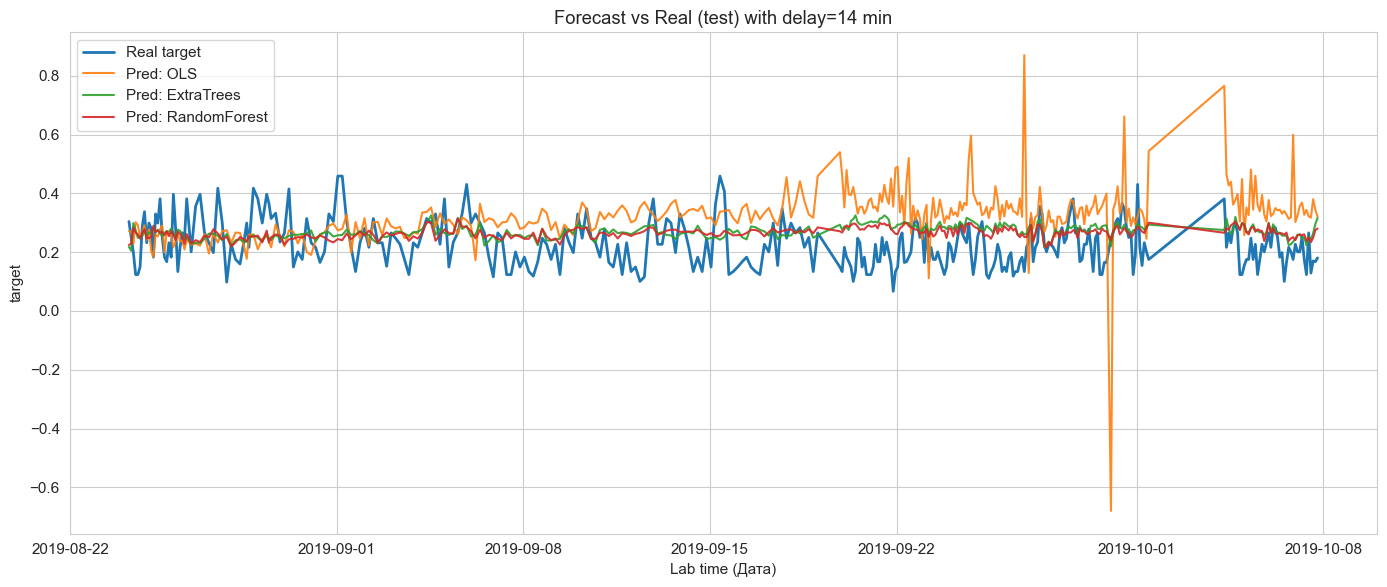

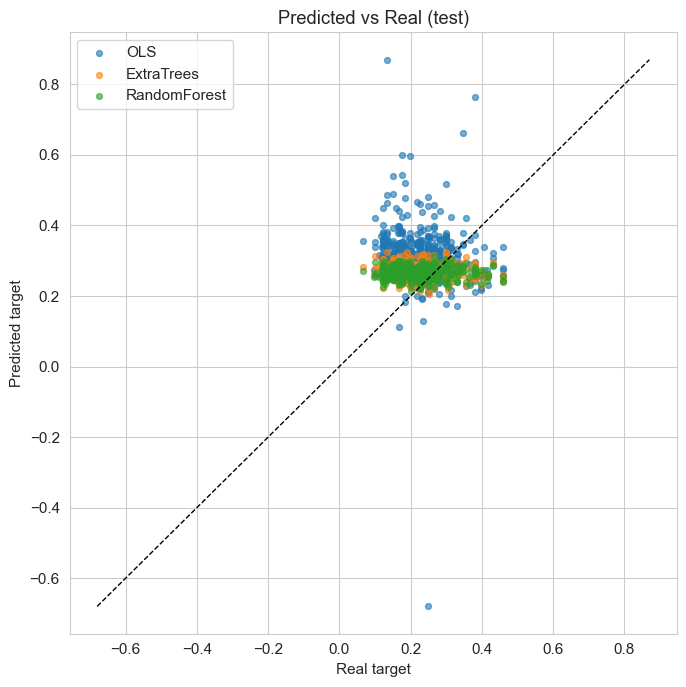

In [23]:
                       
# Набор метрик для сопоставимого сравнения моделей
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - np.asarray(y_pred)) / denom)) * 100.0)

def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    num = np.sum(np.abs(y_true - np.asarray(y_pred)))
    den = np.sum(np.abs(y_true))
    return float(num / den) if den != 0 else np.nan

def directional_accuracy(y_true, y_pred):
    """Доля корректного направления при сравнении соседних точек во времени."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) < 2:
        return np.nan
    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)

    nonzero = dy_true != 0
    if nonzero.sum() == 0:
        return np.nan

    dir_true = np.sign(dy_true[nonzero])
    dir_pred = np.sign(dy_pred[nonzero])
    return float(np.mean(dir_true == dir_pred))

# Фиксируем хронологический порядок тестового сегмента
X_test = X_test.sort_index()
y_test = y_test.sort_index()

results = []
preds_by_model = {}
models = {}

X_train_ols = X_train[selected_features_for_ols]
X_test_ols = X_test[selected_features_for_ols]

X_train_ols_c = sm.add_constant(X_train_ols, has_constant='add')
X_test_ols_c = sm.add_constant(X_test_ols, has_constant='add')

# Модель 1: интерпретируемая линейная база
start_fit = time.time()
ols_model = sm.OLS(y_train.values, X_train_ols_c.values)
ols_res = ols_model.fit()
fit_time = time.time() - start_fit

start_pred = time.time()
pred_ols = ols_res.predict(X_test_ols_c.values)
pred_time = time.time() - start_pred

preds_by_model['OLS'] = pred_ols
models['OLS'] = ols_res

mae_ols = mean_absolute_error(y_test.values, pred_ols)
r_ols = rmse(y_test.values, pred_ols)
mape_ols = mape(y_test.values, pred_ols)
wape_ols = wape(y_test.values, pred_ols)
dir_acc_ols = directional_accuracy(y_test.values, pred_ols)

results.append({
    'model': 'OLS',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    'MAE': mae_ols,
    'RMSE': r_ols,
    'MAPE_%': mape_ols,
    'WAPE': wape_ols,
    'directional_acc': dir_acc_ols,
    'AIC': float(ols_res.aic),
    'BIC': float(ols_res.bic),
})

# Модель 2: нелинейный ансамбль деревьев
start_fit = time.time()
extra_model = ExtraTreesRegressor(
    n_estimators=CONFIG['extra_trees_n_estimators'],
    random_state=CONFIG['random_seed'],
    n_jobs=-1,
    max_depth=CONFIG['extra_trees_max_depth'],
)
extra_model.fit(X_train, y_train.values)
fit_time = time.time() - start_fit

start_pred = time.time()
pred_extra = extra_model.predict(X_test)
pred_time = time.time() - start_pred

preds_by_model['ExtraTrees'] = pred_extra
models['ExtraTrees'] = extra_model

mae = mean_absolute_error(y_test.values, pred_extra)
r = rmse(y_test.values, pred_extra)
mape_v = mape(y_test.values, pred_extra)
wape_v = wape(y_test.values, pred_extra)
dir_acc = directional_accuracy(y_test.values, pred_extra)

results.append({
    'model': 'ExtraTrees',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    'MAE': mae,
    'RMSE': r,
    'MAPE_%': mape_v,
    'WAPE': wape_v,
    'directional_acc': dir_acc,
    'AIC': np.nan,
    'BIC': np.nan,
})

# Модель 3: второй ансамбль для проверки устойчивости качества
start_fit = time.time()
rf_model = RandomForestRegressor(
    n_estimators=CONFIG['rf_n_estimators'],
    random_state=CONFIG['random_seed'],
    n_jobs=-1,
    max_depth=None,
)
rf_model.fit(X_train, y_train.values)
fit_time = time.time() - start_fit

start_pred = time.time()
pred_rf = rf_model.predict(X_test)
pred_time = time.time() - start_pred

preds_by_model['RandomForest'] = pred_rf
models['RandomForest'] = rf_model

mae = mean_absolute_error(y_test.values, pred_rf)
r = rmse(y_test.values, pred_rf)
mape_v = mape(y_test.values, pred_rf)
wape_v = wape(y_test.values, pred_rf)
dir_acc = directional_accuracy(y_test.values, pred_rf)

results.append({
    'model': 'RandomForest',
    'fit_time_s': fit_time,
    'pred_time_s': pred_time,
    'MAE': mae,
    'RMSE': r,
    'MAPE_%': mape_v,
    'WAPE': wape_v,
    'directional_acc': dir_acc,
    'AIC': np.nan,
    'BIC': np.nan,
})

res_df = pd.DataFrame(results).sort_values('MAE')
print(res_df)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, label='Real target', linewidth=2)

for m in preds_by_model:
    ax.plot(y_test.index, preds_by_model[m], label=f'Pred: {m}', alpha=0.9)

ax.set_title(f'Forecast vs Real (test) with delay={best_delay} min')
ax.set_xlabel('Lab time (Дата)')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
for m, yhat in preds_by_model.items():
    ax.scatter(y_test.values, yhat, s=18, alpha=0.6, label=m)

minv = min(y_test.values.min(), min([preds_by_model[m].min() for m in preds_by_model]))
maxv = max(y_test.values.max(), max([preds_by_model[m].max() for m in preds_by_model]))
ax.plot([minv, maxv], [minv, maxv], 'k--', linewidth=1)
ax.set_title('Predicted vs Real (test)')
ax.set_xlabel('Real target')
ax.set_ylabel('Predicted target')
ax.legend()
plt.tight_layout()
plt.show()


## 2.4. Оценка качества моделей (метрики + остатки + интерпретация)

Далее:
- повторно покажем метрики (таблица)
- анализ остатков: нормальность, автокорреляция (Ljung-Box) и гетероскедастичность (Breusch-Pagan)
- важность признаков: SHAP (если доступен) или permutation importance
- дополнительные визуализации: остатки по времени и residuals vs fitted

Best model by MAE: RandomForest
Normality test (D'Agostino K^2): stat=19.8563, pvalue=4.878e-05

Ljung-Box test for autocorrelation:
       lb_stat     lb_pvalue
10  157.999608  8.382612e-29
20  235.764300  8.353535e-39

Breusch-Pagan: LM p-value=0.01663, F p-value=0.01657


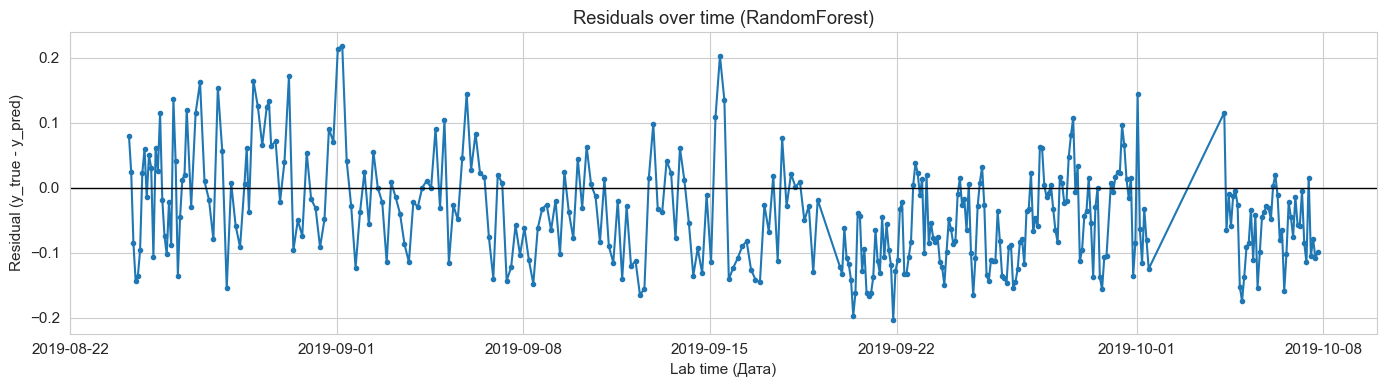

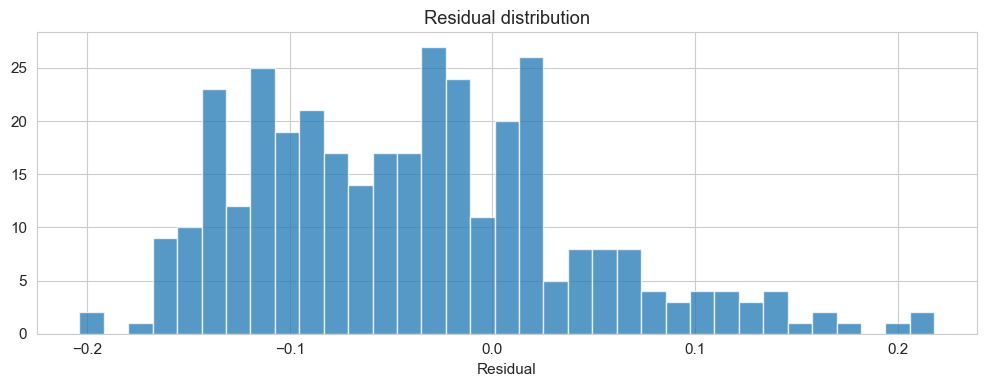

In [ ]:
                                                     
# Диагностику остатков проводим для модели с минимальным MAE
best_model_name = res_df.iloc[0]['model']
best_pred = preds_by_model[best_model_name]

residuals = y_test.values - best_pred

print('Best model by MAE:', best_model_name)

# Проверка нормальности, автокорреляции и гетероскедастичности
nt = stats.normaltest(residuals)
print(f"Normality test (D'Agostino K^2): stat={nt.statistic:.4f}, pvalue={nt.pvalue:.4g}")

lj = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('\nLjung-Box test for autocorrelation:')
print(lj)

exog_bp = sm.add_constant(best_pred, has_constant='add')
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, exog_bp)
print(f"\nBreusch-Pagan: LM p-value={bp_p:.4g}, F p-value={bp_fp:.4g}")

if nt.pvalue < 0.05:
    print('Interpretation: residuals are non-normal (p < 0.05).')
else:
    print('Interpretation: residual normality is not rejected.')

if (lj['lb_pvalue'] < 0.05).any():
    print('Interpretation: residual autocorrelation is present (Ljung-Box p < 0.05).')
else:
    print('Interpretation: no significant residual autocorrelation at selected lags.')

if bp_p < 0.05:
    print('Interpretation: heteroskedasticity is present (Breusch-Pagan p < 0.05).')
else:
    print('Interpretation: heteroskedasticity is not detected.')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, residuals, marker='o', linestyle='-', markersize=3)
ax.axhline(0, color='black', linewidth=1)
ax.set_title(f'Residuals over time ({best_model_name})')
ax.set_xlabel('Lab time (Дата)')
ax.set_ylabel('Residual (y_true - y_pred)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals, bins=35, alpha=0.75)
ax.set_title('Residual distribution')
ax.set_xlabel('Residual')
plt.tight_layout()
plt.show()

print('\nFeature importance...')

feature_importance_df = None

if SHAP_AVAILABLE and best_model_name in ['ExtraTrees', 'RandomForest']:
    try:
        model = models[best_model_name]
                                                                      
        n_shap = min(250, len(X_test))
        X_shap = X_test.iloc[:n_shap]

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)

        plt.figure()
        shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
        plt.tight_layout()
        plt.show()

        if isinstance(shap_values, list):
            shap_values_abs = np.abs(shap_values[0])
        else:
            shap_values_abs = np.abs(shap_values)

        mean_abs = shap_values_abs.mean(axis=0)
        feature_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': mean_abs})
        feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
        print('Top features by SHAP:')
        print(feature_importance_df.head(15))
    except Exception as e:
        print('SHAP failed, fallback to permutation-like importance. Error:', str(e))

if feature_importance_df is None:
    try:
        model = models[best_model_name]
                                                                                             
        if hasattr(model, 'feature_importances_'):
            fi = model.feature_importances_
            k_top = min(30, len(fi))
            top_k_features = X_test.columns[np.argsort(fi)[-k_top:]].tolist()
        else:
            top_k_features = X_test.columns[:30].tolist()

        baseline_mae = mean_absolute_error(y_test.values, model.predict(X_test))

        rng = np.random.RandomState(CONFIG['random_seed'])
        n_repeats = 5

        imp_rows = []
        X_base = X_test.copy()

        for feat in top_k_features:
            maes = []
            for r_i in range(n_repeats):
                X_shuf = X_base.copy()
                X_shuf[feat] = X_shuf[feat].sample(frac=1.0, random_state=int(CONFIG['random_seed'] + r_i)).values
                pred = model.predict(X_shuf)
                maes.append(mean_absolute_error(y_test.values, pred))
            imp_rows.append({'feature': feat, 'perm_importance': float(np.mean(maes) - baseline_mae)})

        feature_importance_df = pd.DataFrame(imp_rows).sort_values('perm_importance', ascending=False)
        print('Top features by permutation-like importance (restricted):')
        print(feature_importance_df.head(15))

        fig, ax = plt.subplots(figsize=(10, 4))
        feature_importance_df.head(15).iloc[::-1].plot(kind='barh', x='feature', y='perm_importance', legend=False, ax=ax)
        ax.set_title('Top-15 feature importances')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Permutation-like importance failed:', str(e))

if feature_importance_df is not None:
    def extract_telemetry_name(feature_name: str):
                                                                                   
        parts = feature_name.split('_')
        if len(parts) >= 2 and parts[0] == 'telemetry':
            return parts[0] + '_' + parts[1]
        return feature_name

    feature_importance_df['telemetry_channel'] = feature_importance_df['feature'].apply(extract_telemetry_name)
    agg = feature_importance_df.groupby('telemetry_channel')['importance'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    agg.head(10).iloc[::-1].plot(kind='barh', ax=ax)
    ax.set_title(f'Top telemetry channels (aggregated) from {best_model_name}')
    ax.set_xlabel('Mean importance')
    plt.tight_layout()
    plt.show()


## Выводы по 2.1-2.4

### 2.1 EDA и синхронизация
- После очистки данных рабочими остались информативные телеметрические каналы; пропуски закрыты интерполяцией.
- По подбору задержки на holdout получено `best_delay = 14` минут.

### 2.2 Признаки
- Признаки рассчитаны в точке `anchor = t_lab - delay`: лаги, rolling-статистики, производные и календарные факторы.
- Набор покрывает и текущее состояние печи, и локальную динамику процесса.

### 2.3 Модели
- На тестовом отрезке лучшая по абсолютной ошибке модель — `RandomForest` (`MAE = 0.0728`, `RMSE = 0.0883`, `WAPE = 0.3224`).
- `ExtraTrees` близок по уровневым метрикам (`MAE = 0.0771`), но дает более высокую directional accuracy (`~0.554` против `~0.518` у `RandomForest`).
- Итоговый выбор зависит от приоритета: минимальная ошибка уровня (`RandomForest`) или точнее направление изменений (`ExtraTrees`).

### 2.4 Качество и интерпретация
- Сравнение моделей подтверждено таблицей `res_df` и графиком `forecast vs real`.
- Остатки лучшей модели статистически неидеальны (есть признаки ненормальности, автокорреляции и гетероскедастичности), поэтому это рабочий baseline, а не финальный физический цифровой двойник процесса.
- Важность признаков проверена через SHAP/fallback; ключевые каналы согласуются с лаговой корреляционной структурой из этапа синхронизации.
